# Class Appearance Counter — Train / Valid / Test
Loads `_annotations.coco.json` from each split folder and reports per-class counts for every split plus a combined overview.

In [1]:
import json
import collections
import os
import matplotlib.pyplot as plt
import numpy as np

## Configuration

In [2]:
# ── Edit these ───────────────────────────────────────────────────────────────
BASE_DIR = "Dataset"   # root folder that contains train/, valid/, test/

SPLITS = {
    "train" : os.path.join(BASE_DIR, "train",  "_annotations.coco.json"),
    "valid" : os.path.join(BASE_DIR, "valid",  "_annotations.coco.json"),
    "test"  : os.path.join(BASE_DIR, "test",   "_annotations.coco.json"),
}

CLASS_NAMES = {
    0: "Garbage-detection",
    1: "Cardboard",
    2: "Clothes",
    3: "Garbage_bag",
    4: "Glass",
    5: "Metal",
    6: "Organic",
    7: "Plastics",
}
NUM_CLASSES = len(CLASS_NAMES)
# ─────────────────────────────────────────────────────────────────────────────

## Load & Count All Splits

In [3]:
def load_coco_counts(filepath):
    """Parse a COCO JSON and return (Counter of category_id, image count, cat map)."""
    assert os.path.exists(filepath), f"File not found: {filepath}"
    with open(filepath) as f:
        data = json.load(f)

    cat_map = {c["id"]: c["name"] for c in data.get("categories", [])}
    counts = collections.Counter({i: 0 for i in range(NUM_CLASSES)})
    for ann in data.get("annotations", []):
        counts[int(ann["category_id"])] += 1

    return counts, len(data.get("images", [])), cat_map


split_counts = {}
split_images = {}
cat_map = {}

for split, path in SPLITS.items():
    counts, n_images, cm = load_coco_counts(path)
    split_counts[split] = counts
    split_images[split] = n_images
    cat_map.update(cm)
    total = sum(counts[i] for i in range(NUM_CLASSES))
    print(f"✅  {split:<6}  |  {n_images:>5} images  |  {total:>6} annotations  |  {path}")

# Fill any missing names from the file's categories block
for cid, name in cat_map.items():
    CLASS_NAMES.setdefault(cid, name)

✅  train   |    657 images  |   12357 annotations  |  Dataset\train\_annotations.coco.json
✅  valid   |     63 images  |     941 annotations  |  Dataset\valid\_annotations.coco.json
✅  test    |     31 images  |     572 annotations  |  Dataset\test\_annotations.coco.json


## Per-Split Count Tables

In [4]:
for split, counts in split_counts.items():
    total = sum(counts[i] for i in range(NUM_CLASSES))
    print(f"\n{'─'*48}")
    print(f"  {split.upper()}  —  {split_images[split]} images  |  {total} annotations")
    print(f"{'─'*48}")
    print(f"  {'ID':<4} {'Name':<20} {'Count':>7}  {'%':>6}")
    print(f"  {'─'*40}")
    for cid in range(NUM_CLASSES):
        pct = counts[cid] / total * 100 if total else 0
        print(f"  {cid:<4} {CLASS_NAMES[cid]:<20} {counts[cid]:>7}  {pct:>5.1f}%")
    print(f"  {'─'*40}")
    print(f"  {'TOTAL':<24} {total:>7}")


────────────────────────────────────────────────
  TRAIN  —  657 images  |  12357 annotations
────────────────────────────────────────────────
  ID   Name                   Count       %
  ────────────────────────────────────────
  0    Garbage-detection          0    0.0%
  1    Cardboard               2082   16.8%
  2    Clothes                 1803   14.6%
  3    Garbage_bag             1563   12.6%
  4    Glass                   1083    8.8%
  5    Metal                   1863   15.1%
  6    Organic                 2034   16.5%
  7    Plastics                1929   15.6%
  ────────────────────────────────────────
  TOTAL                      12357

────────────────────────────────────────────────
  VALID  —  63 images  |  941 annotations
────────────────────────────────────────────────
  ID   Name                   Count       %
  ────────────────────────────────────────
  0    Garbage-detection          0    0.0%
  1    Cardboard                 92    9.8%
  2    Clothes         

## Bar Charts — One per Split

C:\Users\X-COMPUTER\AppData\Local\Temp\ipykernel_21836\1464134782.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
C:\Users\X-COMPUTER\AppData\Local\Temp\ipykernel_21836\1464134782.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
C:\Users\X-COMPUTER\AppData\Local\Temp\ipykernel_21836\1464134782.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)


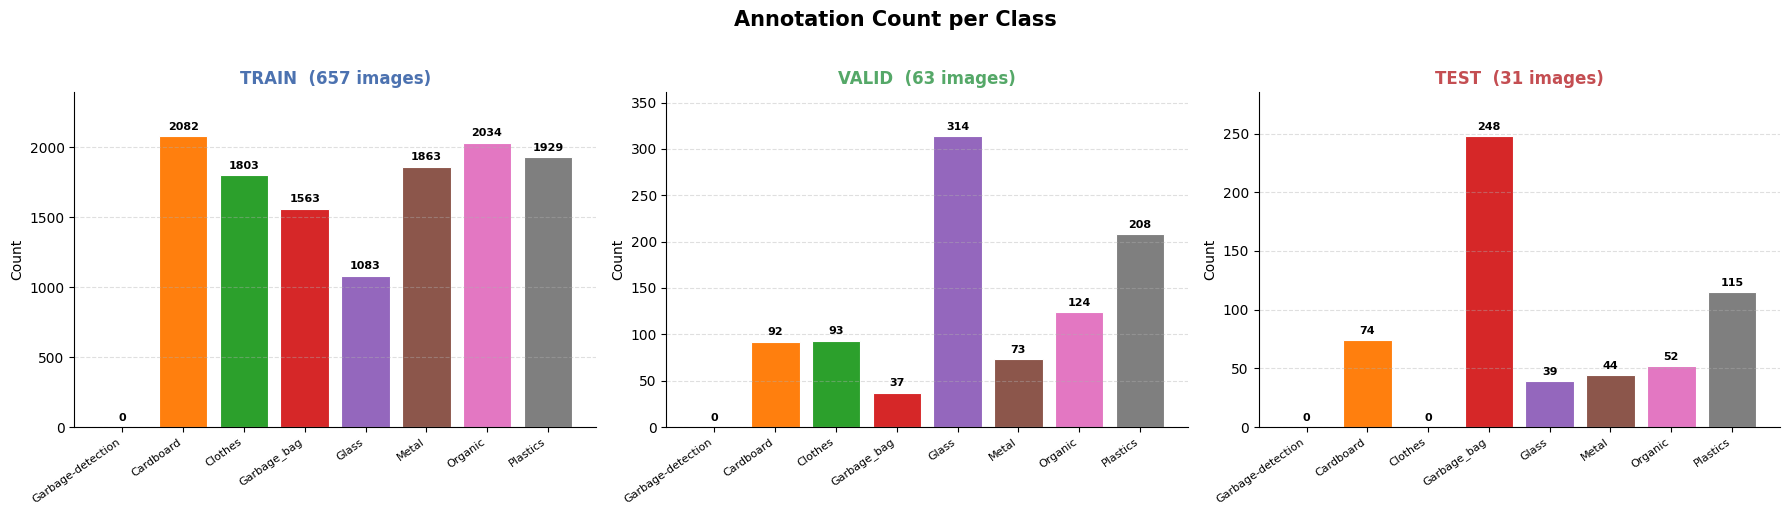

Saved → class_counts_splits.png


In [5]:
labels = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]
colors = plt.cm.tab10.colors[:NUM_CLASSES]
split_colors = {"train": "#4C72B0", "valid": "#55A868", "test": "#C44E52"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle("Annotation Count per Class", fontsize=15, fontweight="bold", y=1.02)

for ax, (split, counts) in zip(axes, split_counts.items()):
    values = [counts[i] for i in range(NUM_CLASSES)]
    bars = ax.bar(labels, values, color=colors, edgecolor="white", linewidth=0.8)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.015,
            str(val), ha="center", va="bottom", fontsize=8, fontweight="bold"
        )

    ax.set_title(
        f"{split.upper()}  ({split_images[split]} images)",
        fontsize=12, fontweight="bold", color=split_colors[split]
    )
    ax.set_ylabel("Count", fontsize=10)
    ax.set_ylim(0, max(values) * 1.15 if max(values) > 0 else 10)
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("class_counts_splits.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → class_counts_splits.png")

## Grouped Bar Chart — All Splits Side by Side

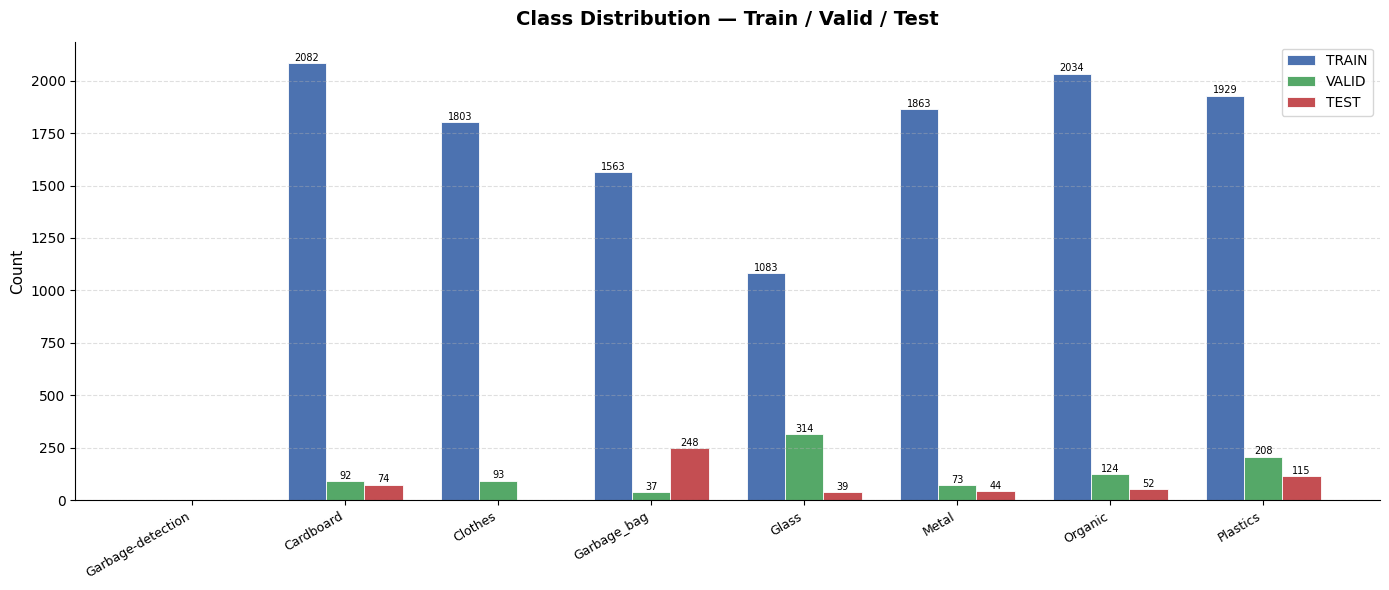

Saved → class_counts_grouped.png


In [6]:
x = np.arange(NUM_CLASSES)
width = 0.25
offsets = [-width, 0, width]

fig, ax = plt.subplots(figsize=(14, 6))

for offset, split in zip(offsets, split_counts):
    values = [split_counts[split][i] for i in range(NUM_CLASSES)]
    bars = ax.bar(x + offset, values, width, label=split.upper(),
                  color=split_colors[split], edgecolor="white", linewidth=0.6)
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                str(val), ha="center", va="bottom", fontsize=7
            )

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Class Distribution — Train / Valid / Test",
             fontsize=14, fontweight="bold", pad=12)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("class_counts_grouped.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → class_counts_grouped.png")

## Combined Summary (All Splits)

In [7]:
combined = collections.Counter({i: 0 for i in range(NUM_CLASSES)})
for counts in split_counts.values():
    combined.update(counts)

grand_total = sum(combined[i] for i in range(NUM_CLASSES))

print(f"\n{'═'*62}")
print(f"  COMBINED  —  {sum(split_images.values())} images  |  {grand_total} annotations")
print(f"{'═'*62}")
print(f"  {'ID':<4} {'Name':<20} {'Total':>7}  {'Train':>7}  {'Valid':>7}  {'Test':>7}")
print(f"  {'─'*56}")
for cid in range(NUM_CLASSES):
    tr = split_counts['train'][cid]
    va = split_counts['valid'][cid]
    te = split_counts['test'][cid]
    print(f"  {cid:<4} {CLASS_NAMES[cid]:<20} {tr+va+te:>7}  {tr:>7}  {va:>7}  {te:>7}")
print(f"  {'─'*56}")
tr_t = sum(split_counts['train'][i] for i in range(NUM_CLASSES))
va_t = sum(split_counts['valid'][i] for i in range(NUM_CLASSES))
te_t = sum(split_counts['test'][i]  for i in range(NUM_CLASSES))
print(f"  {'TOTAL':<24} {grand_total:>7}  {tr_t:>7}  {va_t:>7}  {te_t:>7}")

most_common  = max(range(NUM_CLASSES), key=lambda i: combined[i])
least_common = min(range(NUM_CLASSES), key=lambda i: combined[i])
ratio = combined[most_common] / max(combined[least_common], 1)
print(f"\n  Most common  : {CLASS_NAMES[most_common]} ({combined[most_common]})")
print(f"  Least common : {CLASS_NAMES[least_common]} ({combined[least_common]})")
print(f"  Imbalance ratio (max/min): {ratio:.1f}x")


══════════════════════════════════════════════════════════════
  COMBINED  —  751 images  |  13870 annotations
══════════════════════════════════════════════════════════════
  ID   Name                   Total    Train    Valid     Test
  ────────────────────────────────────────────────────────
  0    Garbage-detection          0        0        0        0
  1    Cardboard               2248     2082       92       74
  2    Clothes                 1896     1803       93        0
  3    Garbage_bag             1848     1563       37      248
  4    Glass                   1436     1083      314       39
  5    Metal                   1980     1863       73       44
  6    Organic                 2210     2034      124       52
  7    Plastics                2252     1929      208      115
  ────────────────────────────────────────────────────────
  TOTAL                      13870    12357      941      572

  Most common  : Plastics (2252)
  Least common : Garbage-detection (0)
  Imb